
# Simulation study on contextual heterogeneity, transportability, and decision quality

This notebook is designed to support a new methodological subsection for the manuscript on replacement prioritization of repairable medical equipment.

It has four goals:

1. Prepare the empirical cohort and define hospital-aware splits.
2. Reproduce simple benchmark models on the real dataset.
3. Run a simulation study that stress-tests contextual heterogeneity and transportability.
4. Compare predictive ranking, probability quality, and downstream decision behavior under explicit loss scenarios.

> Replace paths, tuning choices, and optional model blocks as needed for your final experiments.


In [1]:

# Core imports
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



## 1. Load empirical cohort

Expected file: `analytic_cohort_for_modeling.csv`

This notebook assumes the outcome is `high_downtime_t_plus_1` and that hospitals are identified by `hospital_hash`.


In [2]:

DATA_PATH = "analytic_cohort_for_modeling.csv"  # change if needed

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(14809, 41)


,equip_hash,hospital_hash,year,age_at_year,cm_count,total_downtime_hours,positive_downtime_count,max_downtime,any_downtime,brand_hash,...,any_downtime_lag1,age_lag1,cm_count_expanding_mean_lag1,downtime_expanding_mean_lag1,delta_cm_vs_lag1,delta_downtime_vs_lag1,cm_count_t_plus_1,downtime_t_plus_1,any_downtime_t_plus_1,high_downtime_t_plus_1
0,eq_00339a54eaa6,h_f3391264376f,2022,2.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,eq_00339a54eaa6,h_f3391264376f,2023,3.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,186.0,1.0,1.0
2,eq_00339a54eaa6,h_f3391264376f,2024,4.0,1.0,186.0,1.0,186.0,1,b_b5582bab280c,...,0.0,3.0,0.0,0.0,1.0,186.0,1.0,27.0,1.0,0.0
3,eq_0044d3ea0082,h_b052b2239a62,2023,0.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,eq_0044d3ea0082,h_b052b2239a62,2024,1.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,0.0


In [3]:

target_col = "high_downtime_t_plus_1"
group_col = "hospital_hash"

candidate_features = [
    "age_at_year",
    "cm_count",
    "total_downtime_hours",
    "log_cm_count",
    "log_total_downtime",
    "positive_downtime_count",
    "max_downtime",
    "any_downtime",
    "cm_count_lag1",
    "total_downtime_lag1",
    "any_downtime_lag1",
    "age_lag1",
    "cm_count_expanding_mean_lag1",
    "downtime_expanding_mean_lag1",
    "delta_cm_vs_lag1",
    "delta_downtime_vs_lag1",
]

hospital_context_features = [
    "LEITOS_EXISTENTES_z",
    "LEITOS_SUS_z",
    "UTI_TOTAL_EXIST_z",
    "UTI_TOTAL_SUS_z",
    "UTI_ADULTO_EXIST_z",
    "UTI_ADULTO_SUS_z",
    "UTI_PEDIATRICO_EXIST_z",
    "UTI_PEDIATRICO_SUS_z",
    "UTI_NEONATAL_EXIST_z",
    "UTI_NEONATAL_SUS_z",
]

feature_cols = [c for c in candidate_features + hospital_context_features if c in df.columns]
print(feature_cols)
print("n_features =", len(feature_cols))
print("Outcome prevalence =", df[target_col].mean())
print("Hospitals =", df[group_col].nunique())


['age_at_year', 'cm_count', 'total_downtime_hours', 'log_cm_count', 'log_total_downtime', 'positive_downtime_count', 'max_downtime', 'any_downtime', 'cm_count_lag1', 'total_downtime_lag1', 'any_downtime_lag1', 'age_lag1', 'cm_count_expanding_mean_lag1', 'downtime_expanding_mean_lag1', 'delta_cm_vs_lag1', 'delta_downtime_vs_lag1', 'LEITOS_EXISTENTES_z', 'LEITOS_SUS_z', 'UTI_TOTAL_EXIST_z', 'UTI_TOTAL_SUS_z', 'UTI_ADULTO_EXIST_z', 'UTI_ADULTO_SUS_z', 'UTI_PEDIATRICO_EXIST_z', 'UTI_PEDIATRICO_SUS_z', 'UTI_NEONATAL_EXIST_z', 'UTI_NEONATAL_SUS_z']
n_features = 26
Outcome prevalence = 0.25045580390303196
Hospitals = 39



## 2. Hospital-aware split


In [4]:

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df[group_col]))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

print(train_df.shape, test_df.shape)
print("Train hospitals:", train_df[group_col].nunique())
print("Test hospitals:", test_df[group_col].nunique())
print("Shared hospitals:", len(set(train_df[group_col]).intersection(set(test_df[group_col]))))


(10517, 41) (4292, 41)
Train hospitals: 29
Test hospitals: 10
Shared hospitals: 0



## 3. Benchmark definitions

The notebook includes:
- age-only heuristic
- age + maintenance heuristic
- logistic regression
- gradient boosting

A placeholder block for the hierarchical Bayesian model is included later.


In [5]:

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[target_col].astype(int).values
y_test = test_df[target_col].astype(int).values

numeric_features = feature_cols

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

logit_model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

gboost_model = Pipeline([
    ("prep", ColumnTransformer(
        transformers=[("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features)],
        remainder="drop"
    )),
    ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

logit_model.fit(X_train, y_train)
gboost_model.fit(X_train, y_train)

logit_proba = logit_model.predict_proba(X_test)[:, 1]
gboost_proba = gboost_model.predict_proba(X_test)[:, 1]


In [6]:

def minmax_scale(x):
    x = np.asarray(x, dtype=float)
    if np.nanmax(x) == np.nanmin(x):
        return np.zeros_like(x)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

# Heuristics
age_only_score = minmax_scale(test_df["age_at_year"].fillna(test_df["age_at_year"].median()))

heuristic_cols = [c for c in ["age_at_year", "cm_count", "total_downtime_hours"] if c in test_df.columns]
heuristic_score = sum(minmax_scale(test_df[c].fillna(test_df[c].median())) for c in heuristic_cols) / len(heuristic_cols)

def compute_metrics(y_true, score, topk_frac=0.10):
    score = np.asarray(score, dtype=float)
    order = np.argsort(-score)
    k = max(1, int(np.ceil(topk_frac * len(score))))
    topk_capture = y_true[order[:k]].sum() / max(1, y_true.sum())
    return {
        "AUROC": roc_auc_score(y_true, score),
        "AUPRC": average_precision_score(y_true, score),
        "Brier": brier_score_loss(y_true, np.clip(score, 1e-6, 1-1e-6)),
        "Top10_capture": topk_capture
    }

results = pd.DataFrame({
    "Age-only heuristic": compute_metrics(y_test, age_only_score),
    "Age + maintenance heuristic": compute_metrics(y_test, heuristic_score),
    "Logistic regression": compute_metrics(y_test, logit_proba),
    "Gradient boosting": compute_metrics(y_test, gboost_proba),
}).T

results


,AUROC,AUPRC,Brier,Top10_capture
Age-only heuristic,0.551451,0.172849,0.167969,0.116766
Age + maintenance heuristic,0.622637,0.218333,0.132590,0.179641
Logistic regression,0.634535,0.280580,0.133521,0.196108
Gradient boosting,0.648090,0.282741,0.142203,0.232036



## 4. ROC and PR curves


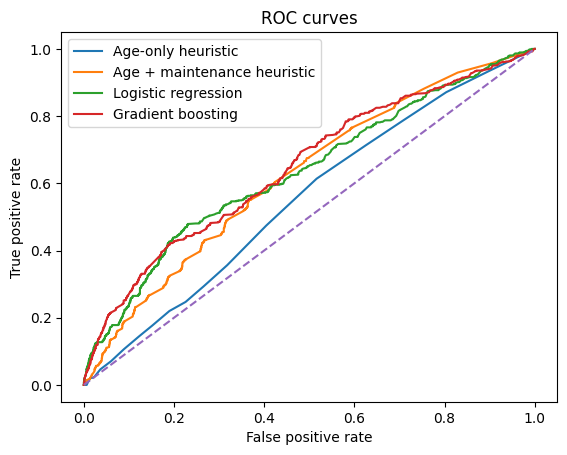

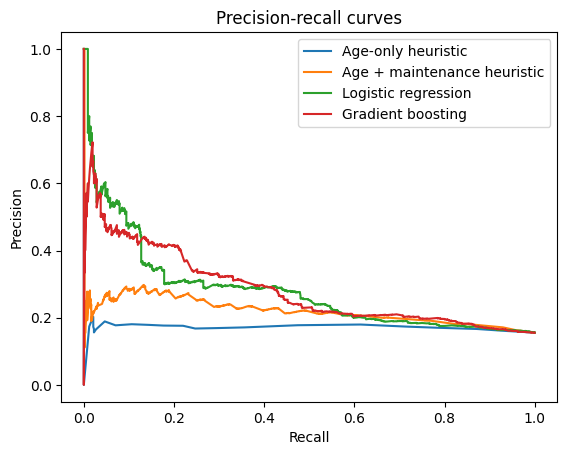

In [7]:

model_scores = {
    "Age-only heuristic": age_only_score,
    "Age + maintenance heuristic": heuristic_score,
    "Logistic regression": logit_proba,
    "Gradient boosting": gboost_proba,
}

for name, score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves")
plt.legend()
plt.show()

for name, score in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves")
plt.legend()
plt.show()



## 5. Top-k capture across prioritization windows


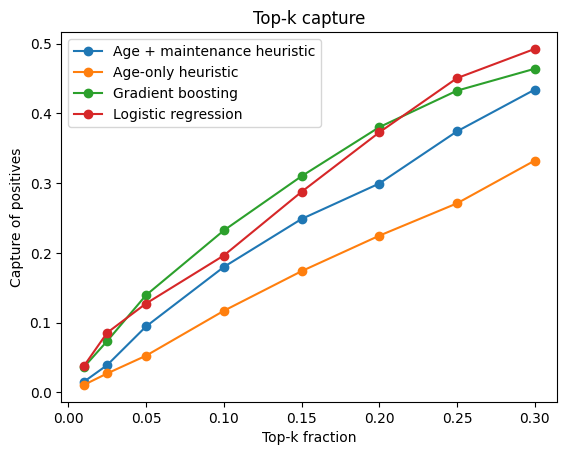

,model,fraction,capture
0,Age-only heuristic,0.010,0.010479
1,Age-only heuristic,0.025,0.026946
2,Age-only heuristic,0.050,0.052395
3,Age-only heuristic,0.100,0.116766
4,Age-only heuristic,0.150,0.173653


In [8]:

fractions = np.array([0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])

topk_df = []
for name, score in model_scores.items():
    for frac in fractions:
        topk_df.append({
            "model": name,
            "fraction": frac,
            "capture": compute_metrics(y_test, score, topk_frac=frac)["Top10_capture"]
        })
topk_df = pd.DataFrame(topk_df)

for name, sub in topk_df.groupby("model"):
    plt.plot(sub["fraction"], sub["capture"], marker="o", label=name)
plt.xlabel("Top-k fraction")
plt.ylabel("Capture of positives")
plt.title("Top-k capture")
plt.legend()
plt.show()

topk_df.head()



## 6. Placeholder: hierarchical Bayesian model on the empirical cohort

This block is intentionally lightweight. It gives you a reproducible template for a hospital-intercept hierarchical logistic model in PyMC. You can expand the predictor set and tuning schedule later.


In [17]:
 # Optional: uncomment after installing pymc and arviz in Colab
 !pip -q install pymc arviz

 import pymc as pm
 import arviz as az

 bayes_features = [c for c in ["age_at_year", "cm_count", "total_downtime_hours"] if c in train_df.columns]

 Xb_train = train_df[bayes_features].copy()
 Xb_test = test_df[bayes_features].copy()

 for c in bayes_features:
     med = Xb_train[c].median()
     std = Xb_train[c].std()
     Xb_train[c] = Xb_train[c].fillna(med)
     Xb_test[c] = Xb_test[c].fillna(med)
     if std > 0:
         Xb_train[c] = (Xb_train[c] - Xb_train[c].mean()) / std
         Xb_test[c] = (Xb_test[c] - Xb_train[c].mean()) / std

 hosp_codes, hosp_uniques = pd.factorize(train_df[group_col])
 test_hosp = pd.Categorical(test_df[group_col], categories=hosp_uniques).codes
 test_hosp = np.where(test_hosp < 0, 0, test_hosp)  # fallback for unseen hospitals

 coords = {
     "obs_id": np.arange(len(train_df)),
     "hospital": np.arange(len(hosp_uniques)),
     "feature": bayes_features,
 }

 with pm.Model(coords=coords) as hierarchical_logit:
     X_data = pm.Data("X_data", Xb_train.values, dims=("obs_id", "feature"))
     y_data = pm.Data("y_data", y_train, dims="obs_id")
     h_data = pm.Data("h_data", hosp_codes, dims="obs_id")

     mu_a = pm.Normal("mu_a", 0, 1.5)
     sigma_a = pm.HalfNormal("sigma_a", 1.0)
     a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="hospital")

     beta = pm.Normal("beta", 0, 1.0, dims="feature")

     eta = a[h_data] + pm.math.dot(X_data, beta)
     p = pm.Deterministic("p", pm.math.sigmoid(eta), dims="obs_id")

     pm.Bernoulli("likelihood", p=p, observed=y_data, dims="obs_id")

     idata = pm.sample(
         draws=1000,
         tune=1000,
         chains=4,
         cores=2,
         target_accept=0.9,
         random_seed=RANDOM_STATE
     )

 az.summary(idata, var_names=["mu_a", "sigma_a", "beta"])


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,-0.954,0.130,-1.193,-0.702,0.002,0.002,4023.0,2600.0,1.0
sigma_a,0.648,0.100,0.467,0.833,0.002,0.002,3502.0,2801.0,1.0
beta[age_at_year],0.051,0.025,0.001,0.094,0.000,0.000,3861.0,2957.0,1.0
beta[cm_count],0.471,0.025,0.423,0.517,0.000,0.000,4140.0,3010.0,1.0
beta[total_downtime_hours],-0.092,0.027,-0.141,-0.041,0.000,0.000,5322.0,3108.0,1.0



## 7. Simulation study design

The simulation section is designed to support a new methodological subsection in the paper.

### Main questions
1. What happens when hospital-level heterogeneity is ignored?
2. How much can random splits overstate performance relative to hospital-aware evaluation?
3. Can a better-calibrated model yield better decisions even when ranking metrics are similar?


In [10]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def simulate_multicenter_data(
    n_hospitals=24,
    min_n=250,
    max_n=900,
    beta=(0.10, 0.55, 0.75),
    sigma_h=0.9,
    seed=42
):
    rng = np.random.default_rng(seed)
    rows = []

    for h in range(n_hospitals):
        n = rng.integers(min_n, max_n + 1)
        hospital_intercept = rng.normal(0.0, sigma_h)
        hospital_shift = rng.normal(0.0, 0.6)

        age = np.clip(rng.normal(8 + hospital_shift, 4.0, n), 0, None)
        cm = rng.poisson(lam=np.clip(1.2 + 0.20 * age + hospital_shift, 0.1, None), size=n)
        downtime = rng.gamma(shape=1.8 + 0.10 * cm, scale=8.0 + 0.2 * age, size=n)

        age_z = (age - age.mean()) / (age.std() + 1e-8)
        cm_z = (cm - cm.mean()) / (cm.std() + 1e-8)
        dt_z = (np.log1p(downtime) - np.log1p(downtime).mean()) / (np.log1p(downtime).std() + 1e-8)

        eta = hospital_intercept + beta[0] * age_z + beta[1] * cm_z + beta[2] * dt_z
        p = sigmoid(eta)
        y = rng.binomial(1, p, size=n)

        rows.append(pd.DataFrame({
            "hospital": f"h_{h:02d}",
            "age": age,
            "cm": cm,
            "downtime": downtime,
            "log_downtime": np.log1p(downtime),
            "y": y,
            "true_p": p
        }))

    return pd.concat(rows, ignore_index=True)

sim_df = simulate_multicenter_data()
sim_df.head()


,hospital,age,cm,downtime,log_downtime,y,true_p
0,h_00,12.212530,8,12.863696,2.629274,0,0.556064
1,h_00,0.646130,2,13.370686,2.665190,1,0.156156
2,h_00,3.241553,1,29.005735,3.401389,1,0.246368
3,h_00,8.961632,3,33.322006,3.535787,0,0.431175
4,h_00,7.185300,7,17.744856,2.930919,1,0.533444


In [11]:

def random_split_scores(df_sim, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df_sim))
    rng.shuffle(idx)
    cut = int(0.75 * len(idx))
    tr, te = idx[:cut], idx[cut:]
    return tr, te

def hospital_split_scores(df_sim):
    groups = df_sim["hospital"].values
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
    tr, te = next(gss.split(df_sim, groups=groups))
    return tr, te

def fit_simple_models(train_df, test_df):
    features = ["age", "cm", "log_downtime"]
    X_train = train_df[features]
    X_test = test_df[features]
    y_train = train_df["y"].values
    y_test = test_df["y"].values

    prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), features)
    ])

    pooled = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
    pooled.fit(X_train, y_train)
    pooled_p = pooled.predict_proba(X_test)[:, 1]

    # hospital fixed-effects proxy for a non-hierarchical context-aware baseline
    train_fe = train_df.copy()
    test_fe = test_df.copy()
    hosp_dummies_train = pd.get_dummies(train_fe["hospital"], prefix="hosp")
    hosp_dummies_test = pd.get_dummies(test_fe["hospital"], prefix="hosp").reindex(columns=hosp_dummies_train.columns, fill_value=0)

    X_train_fe = pd.concat([train_fe[features].reset_index(drop=True), hosp_dummies_train.reset_index(drop=True)], axis=1)
    X_test_fe = pd.concat([test_fe[features].reset_index(drop=True), hosp_dummies_test.reset_index(drop=True)], axis=1)

    fe_prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), X_train_fe.columns.tolist())
    ])

    fixed_effects = Pipeline([("prep", fe_prep), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
    fixed_effects.fit(X_train_fe, y_train)
    fixed_p = fixed_effects.predict_proba(X_test_fe)[:, 1]

    out = pd.DataFrame({
        "model": ["pooled_logit", "hospital_fixed_effects"],
        "AUROC": [roc_auc_score(y_test, pooled_p), roc_auc_score(y_test, fixed_p)],
        "AUPRC": [average_precision_score(y_test, pooled_p), average_precision_score(y_test, fixed_p)],
        "Brier": [brier_score_loss(y_test, pooled_p), brier_score_loss(y_test, fixed_p)],
    })
    return out

# Compare random split vs hospital split
tr_rand, te_rand = random_split_scores(sim_df)
tr_hosp, te_hosp = hospital_split_scores(sim_df)

rand_results = fit_simple_models(sim_df.iloc[tr_rand], sim_df.iloc[te_rand]).assign(split="random")
hosp_results = fit_simple_models(sim_df.iloc[tr_hosp], sim_df.iloc[te_hosp]).assign(split="hospital-aware")

pd.concat([rand_results, hosp_results], ignore_index=True)


,model,AUROC,AUPRC,Brier,split
0,pooled_logit,0.702945,0.700956,0.218265,random
1,hospital_fixed_effects,0.810530,0.816537,0.177618,random
2,pooled_logit,0.683780,0.626476,0.229891,hospital-aware
3,hospital_fixed_effects,0.683412,0.625911,0.232564,hospital-aware



## 8. Decision-quality experiment

This block compares decisions from risk scores under explicit loss assumptions.

The example below uses a simple three-action rule:
- replace when expected miss loss dominates replacement cost
- inspect when replacement is not justified but passive keeping is still too risky
- otherwise keep


In [12]:

def decision_rule(p, inspect_cost=0.20, replace_cost=0.35, miss_penalty=1.50, inspect_effect=0.50):
    p = np.asarray(p, dtype=float)

    loss_keep = miss_penalty * p
    loss_inspect = inspect_cost + inspect_effect * miss_penalty * p
    loss_replace = np.full_like(p, replace_cost)

    stacked = np.vstack([loss_keep, loss_inspect, loss_replace]).T
    actions = np.argmin(stacked, axis=1)
    labels = np.array(["keep", "inspect", "replace"])
    return labels[actions], stacked

def evaluate_decisions(y_true, p, **kwargs):
    actions, losses = decision_rule(p, **kwargs)
    realized_loss = np.choose(
        np.where(actions == "keep", 0, np.where(actions == "inspect", 1, 2)),
        [
            kwargs.get("miss_penalty", 1.50) * y_true,
            kwargs.get("inspect_cost", 0.20) + kwargs.get("inspect_effect", 0.50) * kwargs.get("miss_penalty", 1.50) * y_true,
            np.full_like(y_true, kwargs.get("replace_cost", 0.35), dtype=float),
        ]
    )
    return {
        "avg_loss": realized_loss.mean(),
        "inspect_rate": np.mean(actions == "inspect"),
        "replace_rate": np.mean(actions == "replace"),
        "positive_rate_among_replaced": y_true[actions == "replace"].mean() if np.any(actions == "replace") else np.nan
    }

decision_table = pd.DataFrame({
    "logistic_regression": evaluate_decisions(y_test, logit_proba),
    "gradient_boosting": evaluate_decisions(y_test, gboost_proba),
    "age_maintenance_heuristic": evaluate_decisions(y_test, heuristic_score),
}).T

decision_table


,avg_loss,inspect_rate,replace_rate,positive_rate_among_replaced
logistic_regression,0.232421,0.0,0.359506,0.235256
gradient_boosting,0.265412,0.0,0.598555,0.197742
age_maintenance_heuristic,0.229590,0.0,0.063840,0.273723


In [13]:
scenarios = {
    "inspection_favored": dict(inspect_cost=0.05, replace_cost=0.45, miss_penalty=1.20, inspect_effect=0.20),
    "balanced": dict(inspect_cost=0.08, replace_cost=0.35, miss_penalty=1.50, inspect_effect=0.35),
    "replacement_favored": dict(inspect_cost=0.12, replace_cost=0.25, miss_penalty=1.80, inspect_effect=0.50),
}

score_dict = {
    "logistic_regression": logit_proba,
    "gradient_boosting": gboost_proba,
    "age_maintenance_heuristic": heuristic_score,
}

all_decision_results = []

for scen_name, scen_params in scenarios.items():
    for model_name, score in score_dict.items():
        out = evaluate_decisions(y_test, score, **scen_params)
        out["scenario"] = scen_name
        out["model"] = model_name
        all_decision_results.append(out)

all_decision_results = pd.DataFrame(all_decision_results)
all_decision_results = all_decision_results[
    ["scenario", "model", "avg_loss", "inspect_rate", "replace_rate", "positive_rate_among_replaced"]
]

all_decision_results

,scenario,model,avg_loss,inspect_rate,replace_rate,positive_rate_among_replaced
0,inspection_favored,logistic_regression,0.087260,0.998136,0.000000,NaN
1,inspection_favored,gradient_boosting,0.088180,0.994175,0.000000,NaN
2,inspection_favored,age_maintenance_heuristic,0.099007,0.709692,0.000000,NaN
3,balanced,logistic_regression,0.161294,0.973905,0.023299,0.530000
4,balanced,gradient_boosting,0.164154,0.901678,0.037046,0.440252
5,balanced,age_maintenance_heuristic,0.174221,0.515144,0.000233,1.000000
6,replacement_favored,logistic_regression,0.242346,0.018639,0.929404,0.161695
7,replacement_favored,gradient_boosting,0.235664,0.008388,0.832945,0.168671
8,replacement_favored,age_maintenance_heuristic,0.240433,0.045899,0.233458,0.227545
